# C4.5 — Árbol de Decisión


---


## Descripción

**C4.5** es un algoritmo de aprendizaje supervisado, desarrollado por **J. Ross Quinlan**,
que induce **árboles de decisión** para tareas de **clasificación**. Es la evolución directa
del algoritmo **ID3** (del mismo autor) y su sucesor comercial es **C5.0/See5**.

El árbol se construye mediante **particionamiento recursivo top-down** de los datos: en cada
nodo se elige el atributo que mejor separa las clases según la **razón de ganancia**
(*gain ratio*), una medida basada en la **entropía de la información** que corrige el sesgo de
la *ganancia de información* de ID3 hacia atributos con muchos valores distintos.

Mejoras clave de C4.5 respecto a ID3:

- Manejo de **atributos continuos** (elige umbrales de corte del tipo `A <= t`).
- Manejo de **valores faltantes** en entrenamiento y clasificación (reparto probabilístico).
- **Poda** del árbol (*pessimistic pruning* / *error-based pruning*) para reducir el sobreajuste.
- Uso de **razón de ganancia** en lugar de ganancia de información pura.
- Posibilidad de convertir el árbol en un **conjunto de reglas `if-then`** legibles.

El resultado es un modelo **interpretable** ("caja blanca"): cada predicción se explica por el
camino raíz→hoja que la produjo.


## Bibtex y Referencias

Fuentes académicas (localizables en Google Scholar):

```bibtex
@book{quinlan2014c4,
  title     = {C4.5: programs for machine learning},
  author    = {Quinlan, J. Ross},
  year      = {2014},
  publisher = {Elsevier}
}

@article{quinlan1986induction,
  title     = {Induction of decision trees},
  author    = {Quinlan, J. Ross},
  journal   = {Machine learning},
  volume    = {1},
  number    = {1},
  pages     = {81--106},
  year      = {1986},
  publisher = {Springer}
}

@article{quinlan1996improved,
  title   = {Improved use of continuous attributes in C4.5},
  author  = {Quinlan, J. Ross},
  journal = {Journal of Artificial Intelligence Research},
  volume  = {4},
  pages   = {77--90},
  year    = {1996}
}

@article{wu2008top,
  title     = {Top 10 algorithms in data mining},
  author    = {Wu, Xindong and Kumar, Vipin and Quinlan, J. Ross and Ghosh, Joydeep
               and Yang, Qiang and Motoda, Hiroshi and McLachlan, Geoffrey J.
               and Ng, Angus and Liu, Bing and Yu, Philip S. and others},
  journal   = {Knowledge and Information Systems},
  volume    = {14},
  number    = {1},
  pages     = {1--37},
  year      = {2008},
  publisher = {Springer}
}

@book{breiman1984classification,
  title     = {Classification and regression trees},
  author    = {Breiman, Leo and Friedman, Jerome H. and Olshen, Richard A.
               and Stone, Charles J.},
  year      = {1984},
  publisher = {Wadsworth}
}

@article{kotsiantis2013decision,
  title     = {Decision trees: a recent overview},
  author    = {Kotsiantis, Sotiris B.},
  journal   = {Artificial Intelligence Review},
  volume    = {39},
  number    = {4},
  pages     = {261--283},
  year      = {2013},
  publisher = {Springer}
}
```

**Referencias comentadas**

1. Quinlan, J. R. (1993/2014). *C4.5: Programs for Machine Learning.* — Obra original que
   define el algoritmo.
2. Quinlan, J. R. (1986). *Induction of decision trees.* Machine Learning, 1(1), 81–106. —
   Antecesor ID3 y fundamentos de entropía/ganancia.
3. Quinlan, J. R. (1996). *Improved use of continuous attributes in C4.5.* JAIR, 4, 77–90. —
   Tratamiento de atributos numéricos.
4. Wu, X. et al. (2008). *Top 10 algorithms in data mining.* KAIS, 14(1), 1–37. — C4.5 figura
   como el algoritmo **#1** de la lista.


## Tipo de Modelo

- **Tipo — MÉTODO DE APRENDIZAJE:** Aprendizaje **supervisado** · **Clasificación**
  (particionamiento recursivo *greedy*, top-down).
- **Tipo — por PARÁMETROS:** Modelo **no paramétrico** (la estructura/complejidad del árbol
  crece con los datos; no asume un número fijo de parámetros ni una distribución concreta).
- **Tipo — DATOS DE APRENDIZAJE:** Datos **etiquetados** (tabulares). Atributos de entrada
  **categóricos y/o continuos**; tolera **valores faltantes**. Variable objetivo **discreta**
  (nominal).
- **Tipo — RESULTADO DEL ENTRENAMIENTO:** Un **árbol de decisión** (modelo interpretable),
  equivalente a un **conjunto de reglas `if-then`** mutuamente excluyentes.


## Alg. Entrenamiento

- **C4.5** — inducción *top-down* de árboles de decisión (TDIDT) por particionamiento
  recursivo **voraz (greedy)**, usando la **razón de ganancia (*gain ratio*)** como criterio
  de división y **poda posterior** basada en error para controlar el sobreajuste.


## Supuestos y Restricciones

**Supuestos**

- Los datos de entrenamiento son **representativos** de la población objetivo.
- Los atributos disponibles son **suficientes** para discriminar las clases.
- Las clases son **discretas y mutuamente excluyentes**.
- Los ejemplos se asumen aproximadamente **independientes**.

**Restricciones / limitaciones**

- Es **voraz**: no garantiza el árbol globalmente **óptimo** (óptimos locales).
- Tiende al **sobreajuste** si no se poda (mitigado con poda pesimista / `confidence factor`).
- Genera **fronteras paralelas a los ejes** (*axis-parallel splits*): modela peor relaciones
  lineales oblicuas.
- **Inestabilidad**: pequeñas variaciones en los datos pueden cambiar mucho el árbol
  (alta varianza → motiva *ensembles* como Random Forest).
- Puede **sesgarse** hacia atributos con muchos valores (la *gain ratio* lo mitiga, no lo elimina).
- Diseñado para **clasificación** (la regresión requiere variantes como CART).


---
## Fundamento matemático (criterio de división)

Sea $S$ el conjunto de ejemplos en un nodo y $A$ un atributo candidato con valores
$\{v_1, \dots, v_k\}$ que induce las particiones $S_{v}$.

**Entropía** (impureza del nodo respecto a la clase, con $p_i$ = proporción de la clase $i$):

$$H(S) = -\sum_{i=1}^{c} p_i \,\log_2 p_i$$

**Ganancia de información** (reducción esperada de entropía al dividir por $A$):

$$IG(S, A) = H(S) - \sum_{v \in \text{valores}(A)} \frac{|S_v|}{|S|}\, H(S_v)$$

**Información de división** (*split information*, penaliza atributos muy ramificados):

$$SI(S, A) = -\sum_{v \in \text{valores}(A)} \frac{|S_v|}{|S|}\, \log_2 \frac{|S_v|}{|S|}$$

**Razón de ganancia** (criterio que usa C4.5 — se elige el atributo que la maximiza):

$$\text{GainRatio}(S, A) = \frac{IG(S, A)}{SI(S, A)}$$

Para **atributos continuos**, C4.5 ordena los valores y evalúa umbrales candidatos $t$
(puntos medios entre valores consecutivos con cambio de clase), tratando la prueba binaria
$A \le t$ como si fuera un atributo discreto de dos ramas.


## Pseudocódigo (esquema TDIDT)

```
C4.5(S, Atributos):
    crear nodo N
    si todos los ejemplos de S son de la misma clase C:
        devolver hoja etiquetada C
    si Atributos está vacío:
        devolver hoja con la clase mayoritaria de S
    para cada atributo A en Atributos:
        calcular GainRatio(S, A)      # umbral óptimo si A es continuo
    A* <- atributo con mayor GainRatio
    asignar A* al nodo N
    para cada valor/rama v de A*:
        S_v <- subconjunto de S con A* = v   (o A* <= t / A* > t)
        si S_v está vacío:
            añadir hoja con la clase mayoritaria de S
        si no:
            añadir subárbol C4.5(S_v, Atributos - {A*})
    devolver N
# (Post-proceso) podar el árbol con estimación pesimista del error
```


---
## Demostración práctica en Python

### 1) C4.5 "desde cero" con *gain ratio* — dataset clásico *Play Tennis* (Quinlan)

Implementación mínima y didáctica sobre atributos categóricos. Ejecutable en Colab sin
dependencias externas más allá de la librería estándar.


In [1]:
import math
from collections import Counter

# Dataset clásico "Jugar al tenis" (Quinlan, 1986) — 14 ejemplos
columnas = ["Pronostico", "Temperatura", "Humedad", "Viento", "Jugar"]
datos = [
    ["Soleado",  "Calido",   "Alta",   "Debil",  "No"],
    ["Soleado",  "Calido",   "Alta",   "Fuerte", "No"],
    ["Nublado",  "Calido",   "Alta",   "Debil",  "Si"],
    ["Lluvia",   "Templado", "Alta",   "Debil",  "Si"],
    ["Lluvia",   "Frio",     "Normal", "Debil",  "Si"],
    ["Lluvia",   "Frio",     "Normal", "Fuerte", "No"],
    ["Nublado",  "Frio",     "Normal", "Fuerte", "Si"],
    ["Soleado",  "Templado", "Alta",   "Debil",  "No"],
    ["Soleado",  "Frio",     "Normal", "Debil",  "Si"],
    ["Lluvia",   "Templado", "Normal", "Debil",  "Si"],
    ["Soleado",  "Templado", "Normal", "Fuerte", "Si"],
    ["Nublado",  "Templado", "Alta",   "Fuerte", "Si"],
    ["Nublado",  "Calido",   "Normal", "Debil",  "Si"],
    ["Lluvia",   "Templado", "Alta",   "Fuerte", "No"],
]

filas = [dict(zip(columnas, fila)) for fila in datos]
OBJETIVO = "Jugar"


def entropia(filas):
    """Entropia de Shannon de la clase objetivo."""
    conteo = Counter(f[OBJETIVO] for f in filas)
    n = len(filas)
    return -sum((c / n) * math.log2(c / n) for c in conteo.values())


def particionar(filas, atributo):
    """Agrupa las filas por cada valor del atributo."""
    grupos = {}
    for f in filas:
        grupos.setdefault(f[atributo], []).append(f)
    return grupos


def gain_ratio(filas, atributo):
    """Razon de ganancia (criterio de C4.5) para un atributo categorico."""
    n = len(filas)
    grupos = particionar(filas, atributo)
    info_condicional = sum((len(g) / n) * entropia(g) for g in grupos.values())
    ganancia = entropia(filas) - info_condicional
    split_info = -sum((len(g) / n) * math.log2(len(g) / n) for g in grupos.values())
    return ganancia / split_info if split_info != 0 else 0.0


def c45(filas, atributos):
    """Induccion recursiva del arbol usando gain ratio."""
    clases = [f[OBJETIVO] for f in filas]
    # Caso base 1: nodo puro
    if len(set(clases)) == 1:
        return clases[0]
    # Caso base 2: sin atributos -> clase mayoritaria
    if not atributos:
        return Counter(clases).most_common(1)[0][0]
    # Elegir el mejor atributo por gain ratio
    mejor = max(atributos, key=lambda a: gain_ratio(filas, a))
    arbol = {mejor: {}}
    for valor, subconjunto in particionar(filas, mejor).items():
        restantes = [a for a in atributos if a != mejor]
        arbol[mejor][valor] = c45(subconjunto, restantes)
    return arbol


atributos = [c for c in columnas if c != OBJETIVO]

print("Gain ratio en la raiz:")
for a in atributos:
    print(f"  {a:12s}: {gain_ratio(filas, a):.4f}")

arbol = c45(filas, atributos)
print("\nArbol inducido por C4.5:")
import json
print(json.dumps(arbol, indent=2, ensure_ascii=False))


Gain ratio en la raiz:
  Pronostico  : 0.1564
  Temperatura : 0.0188
  Humedad     : 0.1518
  Viento      : 0.0488

Arbol inducido por C4.5:
{
  "Pronostico": {
    "Soleado": {
      "Humedad": {
        "Alta": "No",
        "Normal": "Si"
      }
    },
    "Nublado": "Si",
    "Lluvia": {
      "Viento": {
        "Debil": "Si",
        "Fuerte": "No"
      }
    }
  }
}


### 2) Función de predicción y prueba

In [2]:
def predecir(arbol, muestra):
    """Recorre el arbol raiz->hoja para clasificar una muestra."""
    if not isinstance(arbol, dict):
        return arbol  # hoja
    atributo = next(iter(arbol))
    valor = muestra.get(atributo)
    ramas = arbol[atributo]
    if valor not in ramas:
        return "??"  # valor no visto en entrenamiento
    return predecir(ramas[valor], muestra)


# Exactitud sobre el propio conjunto de entrenamiento
correctos = sum(predecir(arbol, f) == f[OBJETIVO] for f in filas)
print(f"Exactitud (train): {correctos}/{len(filas)} = {correctos/len(filas):.2%}")

nueva = {"Pronostico": "Soleado", "Temperatura": "Frio",
         "Humedad": "Alta", "Viento": "Fuerte"}
print("Prediccion para", nueva, "->", predecir(arbol, nueva))


Exactitud (train): 14/14 = 100.00%
Prediccion para {'Pronostico': 'Soleado', 'Temperatura': 'Frio', 'Humedad': 'Alta', 'Viento': 'Fuerte'} -> No


### 3) Comparación con scikit-learn

`scikit-learn` no implementa C4.5 tal cual (usa una variante optimizada de **CART**), pero con
`criterion="entropy"` aplica la **ganancia de información** —el mismo fundamento entrópico de
C4.5/ID3—. Sirve como referencia práctica y para visualizar el árbol.


Reglas del arbol (criterio: entropia / ganancia de informacion):

|--- Pronostico_Nublado <= 0.50
|   |--- Humedad_Alta <= 0.50
|   |   |--- Viento_Fuerte <= 0.50
|   |   |   |--- class: Si
|   |   |--- Viento_Fuerte >  0.50
|   |   |   |--- Pronostico_Soleado <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Pronostico_Soleado >  0.50
|   |   |   |   |--- class: Si
|   |--- Humedad_Alta >  0.50
|   |   |--- Pronostico_Lluvia <= 0.50
|   |   |   |--- class: No
|   |   |--- Pronostico_Lluvia >  0.50
|   |   |   |--- Viento_Fuerte <= 0.50
|   |   |   |   |--- class: Si
|   |   |   |--- Viento_Fuerte >  0.50
|   |   |   |   |--- class: No
|--- Pronostico_Nublado >  0.50
|   |--- class: Si



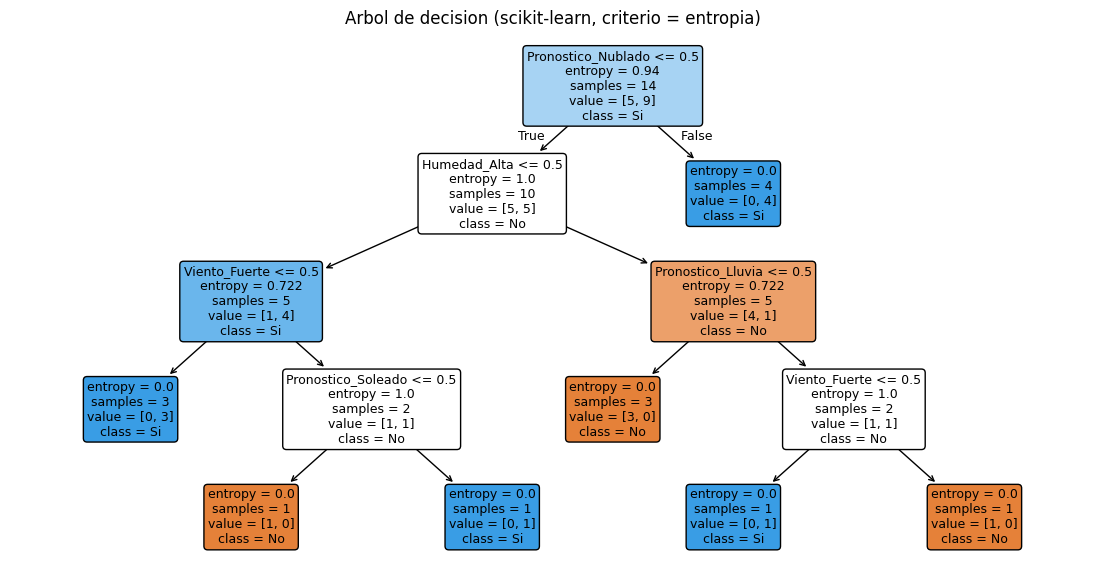

In [3]:
# En Colab scikit-learn ya viene instalado.
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

df = pd.DataFrame(datos, columns=columnas)
X = pd.get_dummies(df[atributos])          # codificacion one-hot de categoricas
y = df[OBJETIVO]

clf = DecisionTreeClassifier(criterion="entropy", random_state=0)
clf.fit(X, y)

print("Reglas del arbol (criterio: entropia / ganancia de informacion):\n")
print(export_text(clf, feature_names=list(X.columns)))

plt.figure(figsize=(14, 7))
plot_tree(clf, feature_names=list(X.columns), class_names=clf.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Arbol de decision (scikit-learn, criterio = entropia)")
plt.show()


### 4) Evaluación sobre un dataset real (Iris)

El ejemplo "Jugar al tenis" es didáctico pero diminuto (14 filas) y se evaluó sobre los mismos datos de entrenamiento. Para cumplir con una evaluación honesta sobre un **dataset real**, entrenamos un árbol estilo C4.5 (`criterion="entropy"`) sobre **Iris** (150 flores, 4 atributos continuos, 3 especies), separando un 30 % de prueba, y reportamos exactitud, matriz de confusión y el árbol resultante. Nótese que aquí el árbol usa cortes binarios sobre atributos continuos — exactamente el mecanismo que C4.5 introdujo sobre ID3 (que solo aceptaba atributos categóricos).

Exactitud en prueba: 0.889

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.81      0.87      0.84        15
   virginica       0.86      0.80      0.83        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



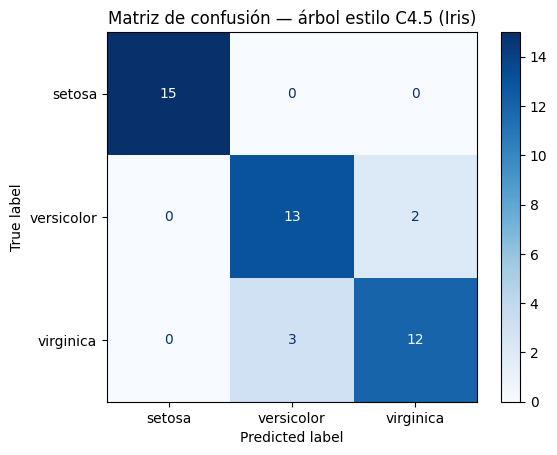

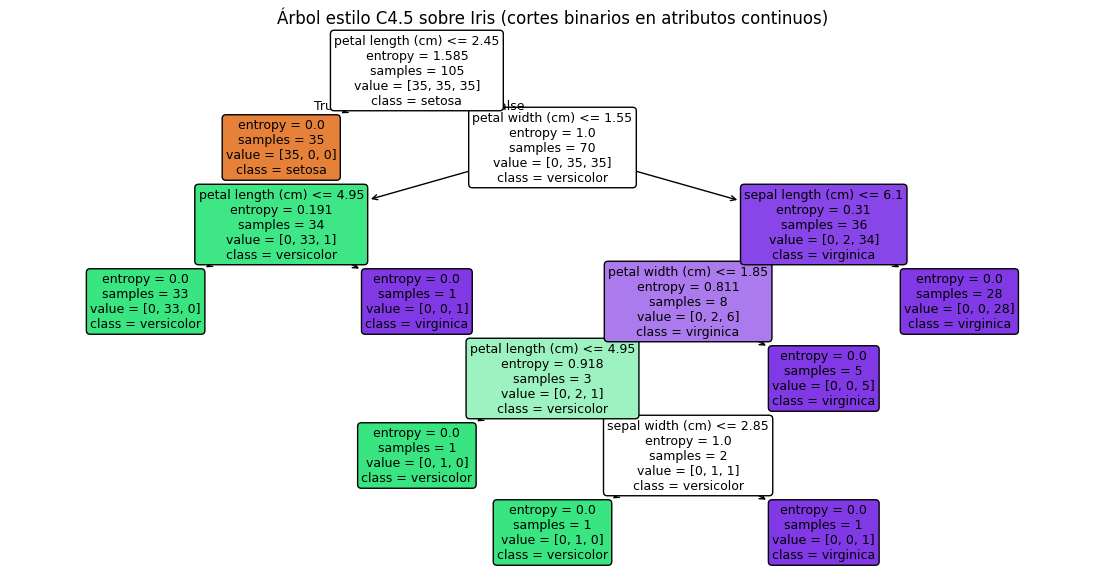

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()
X_tr, X_te, y_tr, y_te = train_test_split(
    iris.data, iris.target, test_size=0.30, random_state=42, stratify=iris.target)

c45_iris = DecisionTreeClassifier(criterion="entropy", random_state=42)
c45_iris.fit(X_tr, y_tr)
y_pred = c45_iris.predict(X_te)

print(f"Exactitud en prueba: {accuracy_score(y_te, y_pred):.3f}\n")
print(classification_report(y_te, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap="Blues")
plt.title("Matriz de confusión — árbol estilo C4.5 (Iris)")
plt.show()

plt.figure(figsize=(14, 7))
plot_tree(c45_iris, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Árbol estilo C4.5 sobre Iris (cortes binarios en atributos continuos)")
plt.show()